# Random forest deep dive - using randomized search for hyperparameter tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Load the Data
print("Loading Data...")
y_train = np.load('../data/vectors/y_train.npy', allow_pickle=True)
y_val = np.load('../data/vectors/y_val.npy', allow_pickle=True)
y_test = np.load('../data/vectors/y_test.npy', allow_pickle=True)

# Route A: TF-IDF + SVD
X_train_svd = np.load('../data/vectors/svd_train.npy')
X_val_svd = np.load('../data/vectors/svd_val.npy')
X_test_svd = np.load('../data/vectors/svd_test.npy')

# Route B: Dense Embeddings
X_train_embed = np.load('../data/vectors/embed_train.npy')
X_val_embed = np.load('../data/vectors/embed_val.npy')
X_test_embed = np.load('../data/vectors/embed_test.npy')

LABELS = ['agree', 'disagree', 'discuss', 'unrelated']

Loading Data...


In [2]:
# 2. Master Evaluation & Plotting Function
def evaluate_tuned_model(model, X_train, y_train, X_val, y_val, X_test, y_test, title_prefix=""):
    print(f"\n{'='*60}\n{title_prefix} MODEL EVALUATION\n{'='*60}")
    print(f"Best Parameters Found: {model.best_params_}")
    
    # Get Predictions
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    # Print Test Classification Report (What the Professor wants to see)
    print("\n--- HOLD-OUT TEST SET CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred_test, labels=LABELS, zero_division=0))
    
    # --- VISUALIZATIONS ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Train vs Val vs Test F1 Score Comparison (To check Overfitting)
    train_f1 = f1_score(y_train, y_pred_train, average=None, labels=LABELS)
    val_f1 = f1_score(y_val, y_pred_val, average=None, labels=LABELS)
    test_f1 = f1_score(y_test, y_pred_test, average=None, labels=LABELS)
    
    df_plot = pd.DataFrame({
        'Stance': LABELS * 3,
        'F1 Score': np.concatenate([train_f1, val_f1, test_f1]),
        'Split': ['Train']*4 + ['Validation']*4 + ['Test']*4
    })
    
    sns.barplot(data=df_plot, x='Stance', y='F1 Score', hue='Split', ax=axes[0], palette='viridis')
    axes[0].set_title(f"{title_prefix} - Overfit Check (F1 Scores)")
    axes[0].set_ylim(0, 1)
    
    # Plot 2: Test Set Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test, labels=LABELS, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
    axes[1].set_title(f"{title_prefix} - Test Set Confusion Matrix")
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    # Return train/val/test macro F1 to quickly spot underfitting/overfitting
    macro_train = f1_score(y_train, y_pred_train, average='macro')
    macro_val = f1_score(y_val, y_pred_val, average='macro')
    macro_test = f1_score(y_test, y_pred_test, average='macro')
    
    print(f"Macro F1 -> Train: {macro_train:.4f} | Val: {macro_val:.4f} | Test: {macro_test:.4f}")
    if (macro_train - macro_val) > 0.15:
        print("⚠️ WARNING: Model is overfitting to the training data.")
    elif macro_train < 0.60:
        print("⚠️ WARNING: Model might be underfitting (high bias).")

Initiating RandomizedSearchCV for Random Forest (This will take a few minutes)...

[1/2] Tuning Random Forest on Route A (TF-IDF + SVD)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Random Forest (TF-IDF + SVD) MODEL EVALUATION
Best Parameters Found: {'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 4, 'clf__n_estimators': 174}

--- HOLD-OUT TEST SET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       agree       0.77      0.75      0.76      1674
    disagree       0.77      0.87      0.82      1153
     discuss       0.85      0.83      0.84      2006
   unrelated       0.89      0.86      0.87      2250

    accuracy                           0.83      7083
   macro avg       0.82      0.83      0.82      7083
weighted avg       0.83      0.83      0.83      7083



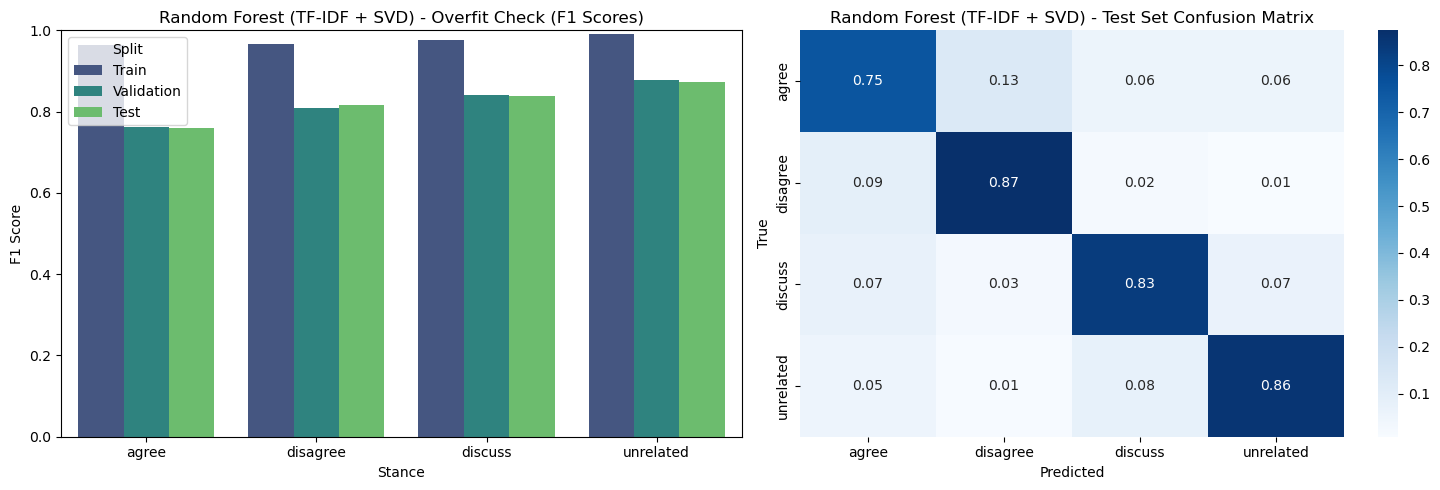

Macro F1 -> Train: 0.9742 | Val: 0.8218 | Test: 0.8220
⚠️ WARNING: Model is overfitting to the training data.

[2/2] Tuning Random Forest on Route B (Dense Embeddings)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Random Forest (Embeddings) MODEL EVALUATION
Best Parameters Found: {'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 4, 'clf__n_estimators': 174}

--- HOLD-OUT TEST SET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       agree       0.87      0.80      0.83      1674
    disagree       0.83      0.94      0.88      1153
     discuss       0.88      0.84      0.86      2006
   unrelated       0.91      0.94      0.93      2250

    accuracy                           0.88      7083
   macro avg       0.87      0.88      0.88      7083
weighted avg       0.88      0.88      0.88      7083



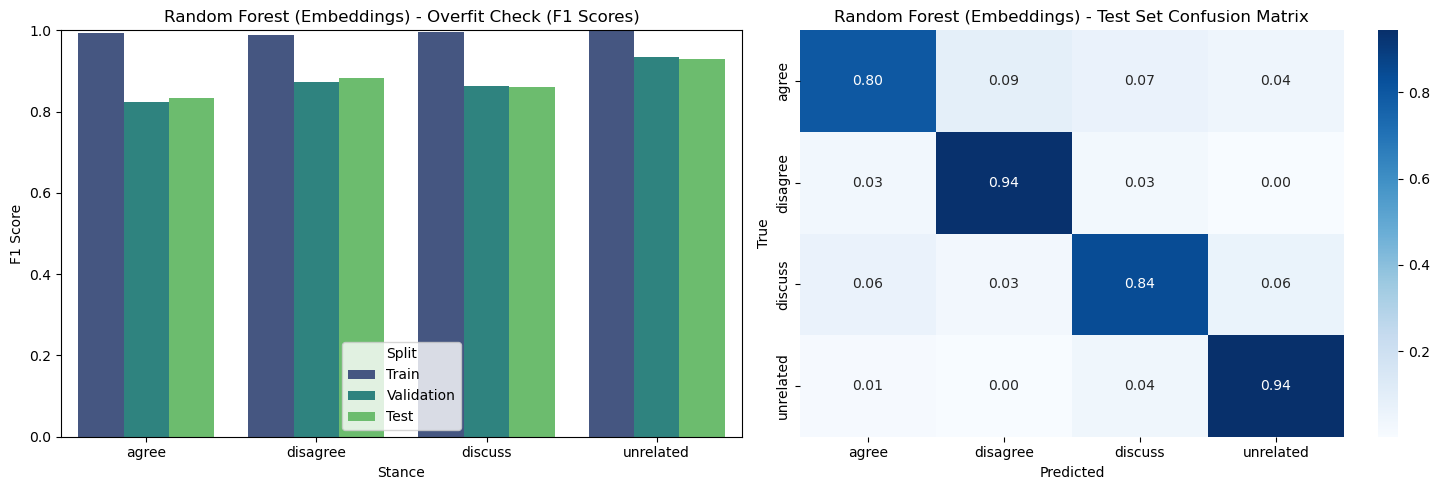

Macro F1 -> Train: 0.9943 | Val: 0.8734 | Test: 0.8767

Saved both tuned Random Forest models to '../models/'.


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# --- RANDOM FOREST SETUP ---
# Note: Tree models don't strictly require scaled data, but keeping the scaler 
# maintains our pipeline architecture and doesn't hurt performance.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Define the Distribution for Randomized Search
# We give it ranges of values, and it will randomly sample 10 combinations to test
param_dist_rf = {
    'clf__n_estimators': randint(100, 300),          # Number of trees
    'clf__max_depth': [10, 15, 20, 30],              # Caps tree depth to prevent overfitting
    'clf__min_samples_split': randint(2, 10),        # Minimum samples required to split a node
    'clf__min_samples_leaf': randint(1, 5)           # Minimum samples required at a leaf node
}

print("Initiating RandomizedSearchCV for Random Forest (This will take a few minutes)...")

# ==========================================
# ROUTE A: TF-IDF + SVD
# ==========================================
print("\n[1/2] Tuning Random Forest on Route A (TF-IDF + SVD)...")
# n_iter=10 means it will try 10 random combinations from our distribution above
random_rf_svd = RandomizedSearchCV(rf_pipeline, param_dist_rf, n_iter=10, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1)
random_rf_svd.fit(X_train_svd, y_train)

# Evaluate
evaluate_tuned_model(random_rf_svd, X_train_svd, y_train, X_val_svd, y_val, X_test_svd, y_test, title_prefix="Random Forest (TF-IDF + SVD)")

# Save Model
joblib.dump(random_rf_svd.best_estimator_, '../models/RF_best_tfidf_svd.pkl')

# ==========================================
# ROUTE B: DENSE EMBEDDINGS
# ==========================================
print("\n[2/2] Tuning Random Forest on Route B (Dense Embeddings)...")
random_rf_embed = RandomizedSearchCV(rf_pipeline, param_dist_rf, n_iter=10, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1)
random_rf_embed.fit(X_train_embed, y_train)

# Evaluate
evaluate_tuned_model(random_rf_embed, X_train_embed, y_train, X_val_embed, y_val, X_test_embed, y_test, title_prefix="Random Forest (Embeddings)")

# Save Model
joblib.dump(random_rf_embed.best_estimator_, '../models/RF_best_embeddings.pkl')

print("\nSaved both tuned Random Forest models to '../models/'.")